# 06 定位與匹配

這個 notebook 記錄如何在接近工業檢測的影像中完成 **localization（定位）** 與 **matching（匹配）**，並且進一步判斷定位結果是否可靠。

這一章的主線不是把 OpenCV 函式各自示範一次，而是建立一條完整思路：

```text
先知道定位結果是什麼
→ 確認影像座標與 ROI 裁切
→ 從 mask 或 contour 得到物件位置
→ 用 template matching 找固定外觀目標
→ 用 multi-scale matching 處理尺度變化
→ 用 feature matching 找局部對應
→ 用 homography 把局部對應轉成物件級定位
→ 用可靠性分析判斷結果能不能被相信
```

最重要的觀念是：

> Localization 不是「圖上畫出一個框」就結束，而是要產生一個能被後續程式使用、也能被證據檢查的位置結果。

因此每個方法都會搭配具體影像、程式碼、結果圖與工程觀察。

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
from IPython.display import display

OUTPUT_DIR = Path("outputs/06_localization_and_matching")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 每一節都會用到的影像顯示函式。
# 對 binary mask 固定 vmin/vmax，避免黑白影像被 matplotlib 自動縮放誤導。
def show_images(images, titles, figsize=(16, 5), save_path=None):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), 1):
        plt.subplot(1, len(images), i)
        if img.ndim == 2:
            if np.issubdtype(img.dtype, np.floating):
                plt.imshow(img, cmap="gray")
            else:
                plt.imshow(img, cmap="gray", vmin=0, vmax=255)
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()

# Response map 通常是浮點數影像。
# 這個函式只為了視覺化把它轉成 0-255。
def normalize_to_u8(arr):
    arr = arr.astype(np.float32)
    mn, mx = float(arr.min()), float(arr.max())
    if mx - mn < 1e-8:
        return np.zeros(arr.shape, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)

# 使用 OpenCV 常見格式 (x, y, width, height) 畫出定位框。
def draw_box(img, box, color=(0,255,0), label=None, thickness=2, center=True):
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if img.ndim == 2 else img.copy()
    x, y, w, h = map(int, box)
    cv2.rectangle(vis, (x,y), (x+w,y+h), color, thickness)
    if center:
        cv2.circle(vis, (x+w//2, y+h//2), 4, (0,0,255), -1)
    if label:
        cv2.putText(vis, label, (x, max(16, y-7)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return vis

# 裁切定位到的 Region of Interest。
# 重要：NumPy 影像裁切順序是 [y:y+h, x:x+w]。
def crop_roi(img, box):
    x, y, w, h = map(int, box)
    return img[y:y+h, x:x+w].copy()


In [2]:
# 本 notebook 使用的工業風格影像產生函式。
# 這些場景是可控範例，不是隨便畫的玩具圖。
# 每個元素都對應特定 localization 概念。

def create_industrial_board(width=760, height=500, seed=3):
    rng = np.random.default_rng(seed)
    xgrad = np.linspace(25, 45, width)[None, :]
    ygrad = np.linspace(0, 12, height)[:, None]
    img = np.clip(xgrad + ygrad + rng.normal(0, 2.5, (height, width)), 0, 255).astype(np.uint8)
    cv2.rectangle(img, (95,65), (665,415), 92, -1)
    cv2.rectangle(img, (95,65), (665,415), 155, 2)
    for yy in range(90,395,38): cv2.line(img, (120,yy), (640,yy), 115, 1)
    for xx in range(140,640,62): cv2.line(img, (xx,90), (xx,390), 108, 1)
    chips = {'U1':(160,130,115,75), 'U2':(435,120,135,85), 'IC_A':(290,270,150,80)}
    for name,(cx,cy,cw,ch) in chips.items():
        cv2.rectangle(img,(cx,cy),(cx+cw,cy+ch),42,-1)
        cv2.rectangle(img,(cx,cy),(cx+cw,cy+ch),185,2)
        for px in range(cx+8,cx+cw-8,12):
            cv2.rectangle(img,(px,cy-7),(px+5,cy),170,-1)
            cv2.rectangle(img,(px,cy+ch),(px+5,cy+ch+7),170,-1)
        cv2.putText(img,name,(cx+12,cy+ch//2+5),cv2.FONT_HERSHEY_SIMPLEX,0.55,205,1,cv2.LINE_AA)
    fiducials=[(135,95),(625,388),(610,95)]
    for fx,fy in fiducials:
        cv2.circle(img,(fx,fy),22,205,-1); cv2.circle(img,(fx,fy),14,45,-1); cv2.circle(img,(fx,fy),5,215,-1)
        cv2.line(img,(fx-26,fy),(fx+26,fy),190,1); cv2.line(img,(fx,fy-26),(fx,fy+26),190,1)
    return cv2.GaussianBlur(img,(3,3),0), {'chips':chips, 'fiducials':fiducials}

def create_plain_fixture(width=760, height=500, seed=30):
    rng=np.random.default_rng(seed)
    img=np.full((height,width),38,np.uint8)
    img=(img+rng.normal(0,2,img.shape)).clip(0,255).astype(np.uint8)
    cv2.rectangle(img,(95,65),(665,415),90,-1); cv2.rectangle(img,(95,65),(665,415),150,2)
    for yy in range(90,395,38): cv2.line(img,(120,yy),(640,yy),108,1)
    for xx in range(140,640,62): cv2.line(img,(xx,90),(xx,390),103,1)
    return cv2.GaussianBlur(img,(3,3),0)

def create_shape_part_scene(seed=9):
    rng=np.random.default_rng(seed)
    img=np.full((420,720),35,np.uint8)
    img=(img+rng.normal(0,2,img.shape)).clip(0,255).astype(np.uint8)
    cv2.rectangle(img,(50,45),(670,370),72,-1); cv2.rectangle(img,(50,45),(670,370),135,2)
    cv2.circle(img,(150,140),38,205,-1); cv2.rectangle(img,(250,95),(350,180),195,-1)
    cv2.ellipse(img,(490,135),(65,36),22,0,360,200,-1); cv2.rectangle(img,(140,255),(270,320),188,-1)
    cv2.fillPoly(img,[np.array([[435,245],[530,325],[370,325]],np.int32)],198)
    # Add many small bright dots so mask cleanup has a visible purpose.
    for _ in range(45):
        cv2.circle(img,(int(rng.integers(70,650)),int(rng.integers(65,350))),int(rng.integers(1,4)),int(rng.integers(175,235)),-1)
    return cv2.GaussianBlur(img,(3,3),0)

def create_rotated_part_scene(seed=12):
    rng=np.random.default_rng(seed)
    img=np.full((420,720),35,np.uint8)
    img=(img+rng.normal(0,2,img.shape)).clip(0,255).astype(np.uint8)
    cv2.rectangle(img,(50,45),(670,370),70,-1); cv2.rectangle(img,(50,45),(670,370),130,2)
    rect=((375,215),(210,75),31)
    box=cv2.boxPoints(rect).astype(np.int32)
    cv2.drawContours(img,[box],0,200,-1); cv2.drawContours(img,[box],0,235,2)
    cv2.circle(img,(180,165),45,195,-1); cv2.circle(img,(180,165),18,70,-1)
    return cv2.GaussianBlur(img,(3,3),0)

def make_fiducial_template(board, center=(135,95), size=62):
    x=int(center[0]-size//2); y=int(center[1]-size//2)
    return board[y:y+size,x:x+size].copy()

def match_template(scene, template, method=cv2.TM_CCOEFF_NORMED):
    response=cv2.matchTemplate(scene, template, method)
    _,score,_,location=cv2.minMaxLoc(response)
    return response, float(score), location

def rotate_image_bound(image, angle, border_value=80):
    h,w=image.shape[:2]
    center=(w/2,h/2)
    M=cv2.getRotationMatrix2D(center, angle, 1.0)
    cos,sin=abs(M[0,0]),abs(M[0,1])
    new_w=int(h*sin+w*cos); new_h=int(h*cos+w*sin)
    M[0,2]+=new_w/2-center[0]; M[1,2]+=new_h/2-center[1]
    return cv2.warpAffine(image, M, (new_w,new_h), borderValue=border_value)

def create_template_scene(base, template, true_pos=(430,300), clutter=False, scale=1.0, rotate_angle=0, illum=1.0):
    scene=np.clip(base.astype(np.float32)*illum,0,255).astype(np.uint8)
    templ=template.copy()
    if scale!=1.0: templ=cv2.resize(templ,None,fx=scale,fy=scale,interpolation=cv2.INTER_CUBIC if scale>1 else cv2.INTER_AREA)
    if rotate_angle!=0: templ=rotate_image_bound(templ, rotate_angle, border_value=int(np.median(scene)))
    h,w=templ.shape; x,y=true_pos
    scene[y:y+h,x:x+w]=templ
    if clutter:
        for cx,cy,alpha,scl in [(120,300,0.82,1.0),(565,105,0.78,1.0),(290,90,0.62,0.92)]:
            t2=cv2.resize(template,None,fx=scl,fy=scl,interpolation=cv2.INTER_AREA)
            hh,ww=t2.shape
            scene[cy:cy+hh,cx:cx+ww]=np.clip(scene[cy:cy+hh,cx:cx+ww].astype(np.float32)*(1-alpha)+t2.astype(np.float32)*alpha,0,255).astype(np.uint8)
    return scene, templ, (x,y,w,h)

def top_k_locations(response, k=5, min_distance=30):
    resp=response.copy(); locs=[]
    for _ in range(k):
        _,score,_,loc=cv2.minMaxLoc(resp)
        x,y=loc; locs.append((x,y,float(score)))
        resp[max(0,y-min_distance):min(resp.shape[0],y+min_distance+1), max(0,x-min_distance):min(resp.shape[1],x+min_distance+1)] = -np.inf
    return locs

def draw_topk(scene, topk, template_shape):
    vis=cv2.cvtColor(scene, cv2.COLOR_GRAY2BGR)
    th,tw=template_shape
    for i,(x,y,score) in enumerate(topk,1):
        color=(0,255,0) if i==1 else (0,180,255)
        cv2.rectangle(vis,(x,y),(x+tw,y+th),color,2)
        cv2.putText(vis,f'{i}:{score:.2f}',(x,max(15,y-6)),cv2.FONT_HERSHEY_SIMPLEX,0.45,color,1)
    return vis

def create_feature_panel(size=220):
    img=np.full((size,size),84,np.uint8)
    cv2.rectangle(img,(12,12),(size-12,size-12),182,3)
    cv2.rectangle(img,(35,40),(100,95),52,-1); cv2.rectangle(img,(122,40),(182,95),132,-1)
    cv2.circle(img,(55,155),28,210,-1); cv2.circle(img,(55,155),12,55,-1)
    cv2.line(img,(120,135),(190,185),215,4); cv2.line(img,(190,135),(120,185),215,4)
    for i,xx in enumerate(range(35,185,12)): cv2.rectangle(img,(xx,105),(xx+5,105+30+(i%4)*10),235 if i%2 else 30,-1)
    cv2.putText(img,'A17',(118,78),cv2.FONT_HERSHEY_SIMPLEX,0.75,235,2,cv2.LINE_AA)
    return cv2.GaussianBlur(img,(3,3),0)

def create_homography_scene(template, scene_size=(560,800), seed=20):
    rng=np.random.default_rng(seed)
    scene=np.full(scene_size,45,np.uint8)
    scene=(scene+rng.normal(0,2,scene.shape)).clip(0,255).astype(np.uint8)
    cv2.rectangle(scene,(70,60),(720,500),70,-1); cv2.rectangle(scene,(70,60),(720,500),135,2)
    for x in range(110,700,70): cv2.line(scene,(x,80),(x,480),86,1)
    h,w=template.shape
    src=np.float32([[0,0],[w-1,0],[w-1,h-1],[0,h-1]])
    dst=np.float32([[360,115],[610,145],[565,420],[310,360]])
    H=cv2.getPerspectiveTransform(src,dst)
    warped=cv2.warpPerspective(template,H,(scene.shape[1],scene.shape[0]))
    mask=cv2.warpPerspective(np.ones_like(template,np.uint8)*255,H,(scene.shape[1],scene.shape[0]))
    scene[mask>0]=warped[mask>0]
    return cv2.GaussianBlur(scene,(3,3),0), src, dst


def create_low_texture_and_repetitive():
    # 建立兩個 feature matching 容易出問題的影像。
    # weak_texture 幾乎沒有明顯角點；repetitive_pattern 則有太多相似小方塊。
    weak = np.full((220, 220), 128, dtype=np.uint8)
    cv2.rectangle(weak, (40, 60), (180, 160), 138, -1)
    cv2.circle(weak, (110, 110), 35, 142, -1)
    weak = cv2.GaussianBlur(weak, (5,5), 0)

    repetitive = np.full((220, 220), 90, dtype=np.uint8)
    for y in range(20, 200, 24):
        for x in range(20, 200, 24):
            cv2.rectangle(repetitive, (x,y), (x+11,y+11), 210, -1)
    repetitive = cv2.GaussianBlur(repetitive, (3,3), 0)

    return weak, repetitive



## 1. What is Localization?

**Localization** 指的是找出目標在影像中的位置。

如果 classification 是回答「這張圖裡是什麼」，那 localization 就是回答「這個東西在哪裡」。在工程流程中，這個「在哪裡」通常不是一句描述，而是一組可以被程式使用的資料，例如：

```text
bounding box: (x, y, w, h)
center point: (cx, cy)
polygon boundary
ROI crop
```

`ROI` 是 **Region of Interest**，意思是感興趣區域，也就是後續要繼續分析的影像區塊。舉例來說，如果先在電路板影像中定位出 `U1` 晶片，就可以把這個晶片區域裁切出來，再送去做瑕疵檢測、OCR、尺寸量測或分類。

這一節的重點是建立「定位結果是工程資料」的概念。綠色框只是視覺化，真正重要的是框背後的 `(x, y, w, h)`。

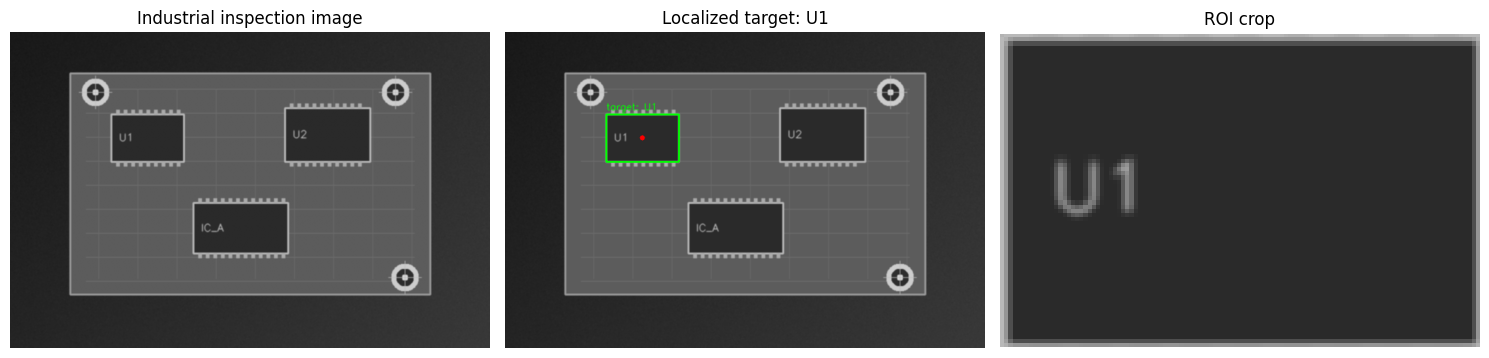

In [3]:
board, metadata = create_industrial_board()
target_box = metadata['chips']['U1']
localized = draw_box(board, target_box, label='target: U1')
roi = crop_roi(board, target_box)
show_images([board, localized, roi], ['Industrial inspection image', 'Localized target: U1', 'ROI crop'], figsize=(15,5), save_path=OUTPUT_DIR/'01_what_is_localization.png')

### 工程觀察

結果圖中，綠色框標出 `U1` 晶片的位置，紅點標出 bounding box 的中心，右側 ROI 則是根據同一組 box 座標裁切出的區域。

這裡要注意一個工程細節：  
如果 bounding box 只是畫在圖上看起來正確，但無法正確裁切出 ROI，那它對後續 pipeline 沒有實際價值。

所以 localization 的結果應該同時滿足兩件事：

```text
1. 視覺上框到正確目標
2. 數值上能正確裁切、量測或傳給下一階段
```

## 2. Image Coordinate System

在 OpenCV 與 NumPy 中，影像座標系統和一般數學座標系不同。

```text
origin = 左上角
x      = 往右增加
y      = 往下增加
```

常見 bounding box 格式是：

```text
(x, y, w, h)
```

其中 `(x, y)` 是 box 左上角，`w` 是寬度，`h` 是高度。

最容易出錯的是 ROI 裁切。NumPy 的影像陣列索引順序是：

```python
image[y:y+h, x:x+w]
```

不是：

```python
image[x:x+w, y:y+h]
```

這個細節很重要，因為一旦 x/y 順序混淆，後面所有裁切、量測與標註都會跟著錯。

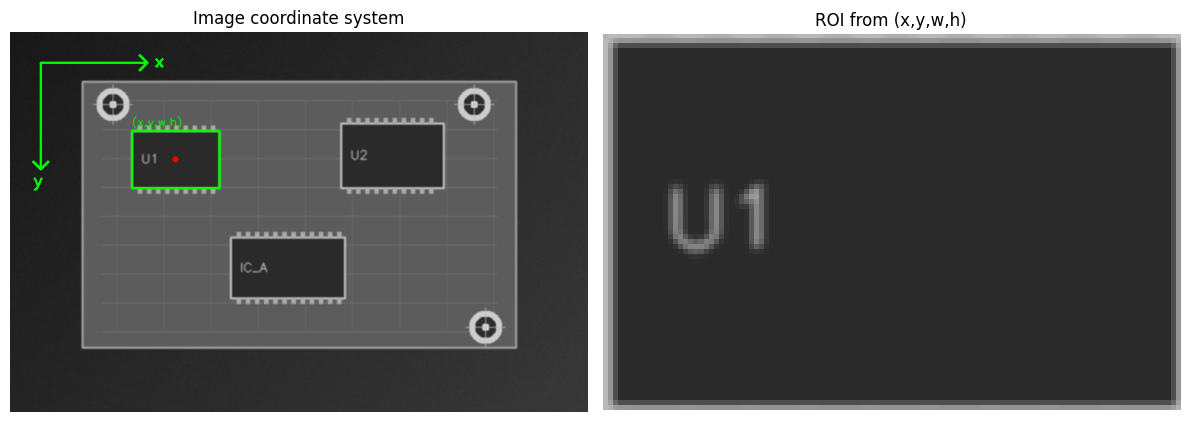

In [4]:
coord = cv2.cvtColor(board, cv2.COLOR_GRAY2BGR)
cv2.arrowedLine(coord,(40,40),(180,40),(0,255,0),2)
cv2.arrowedLine(coord,(40,40),(40,180),(0,255,0),2)
cv2.putText(coord,'x',(190,45),cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,255,0),2)
cv2.putText(coord,'y',(31,202),cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,255,0),2)
coord = draw_box(coord, target_box, label='(x,y,w,h)')
show_images([coord, roi], ['Image coordinate system','ROI from (x,y,w,h)'], figsize=(12,5), save_path=OUTPUT_DIR/'02_coordinate_system_and_roi.png')

## 3. Localization from Binary Mask

**Mask-based localization** 的核心想法是：

> 先把「哪些 pixels 屬於前景」找出來，再把相連的前景 pixels 組成物件。

流程通常是：

```text
grayscale image
→ thresholding
→ morphology cleanup
→ connected components
→ bounding boxes and centroids
```

`CCL` 是 **Connected Component Labeling**，意思是把相連的 foreground pixels 分組。每一組 connected component 都可以被視為一個候選物件，並進一步計算 area、bounding box、centroid 等資訊。

這個方法適合用在「目標和背景亮度差異明顯」的情境，例如亮色零件放在暗色治具上。它的優點是直覺、可解釋、速度快；缺點是很依賴 mask 品質。

這一節刻意在影像中加入許多小白點，因為如果 clean mask 沒有真的把這些小白點清掉，那後續 connected components 就可能把雜訊也當成候選物件。

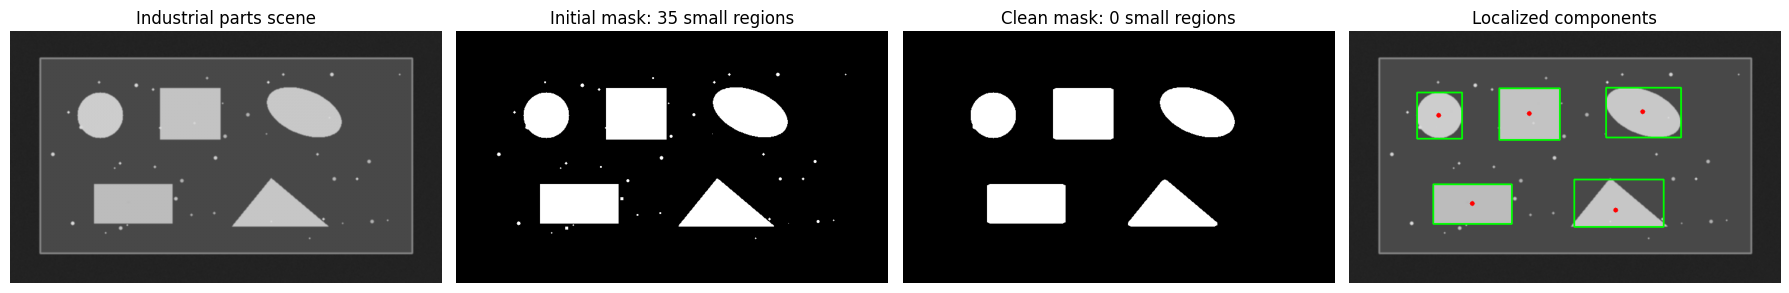

,id,x,y,w,h,area,centroid_x,centroid_y
0,1,250,95,101,86,8662,300.00,137.50
1,2,428,94,125,83,7495,489.97,135.00
2,3,113,102,75,77,4524,149.91,140.06
3,4,375,247,149,79,6506,444.96,298.35
4,5,140,255,131,66,8622,205.00,287.50


In [5]:
shape = create_shape_part_scene()
_, mask_initial = cv2.threshold(shape, 135, 255, cv2.THRESH_BINARY)
k5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
k7 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
mask_clean = cv2.morphologyEx(mask_initial, cv2.MORPH_OPEN, k5, iterations=2)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, k7, iterations=1)
num_i, _, stats_i, _ = cv2.connectedComponentsWithStats(mask_initial, 8)
num_c, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_clean, 8)
small_initial = sum(1 for i in range(1, num_i) if stats_i[i, cv2.CC_STAT_AREA] < 1000)
small_clean = sum(1 for i in range(1, num_c) if stats[i, cv2.CC_STAT_AREA] < 1000)
result = cv2.cvtColor(shape, cv2.COLOR_GRAY2BGR)
rows=[]
for i in range(1, num_c):
    x,y,w,h,area = stats[i]
    if area < 1000: continue
    cx,cy = centroids[i]
    rows.append({'id':len(rows)+1,'x':int(x),'y':int(y),'w':int(w),'h':int(h),'area':int(area),'centroid_x':round(float(cx),2),'centroid_y':round(float(cy),2)})
    cv2.rectangle(result,(x,y),(x+w,y+h),(0,255,0),2)
    cv2.circle(result,(int(cx),int(cy)),4,(0,0,255),-1)
df_mask = pd.DataFrame(rows)
show_images([shape, mask_initial, mask_clean, result], ['Industrial parts scene', f'Initial mask: {small_initial} small regions', f'Clean mask: {small_clean} small regions', 'Localized components'], figsize=(18,5), save_path=OUTPUT_DIR/'03_mask_based_localization.png')
df_mask

### 工程觀察

這一節不能只看最後是否畫出 bounding boxes，而要先看 mask 是否可信。

`Initial mask` 中會有許多小白點，這些是 thresholding 後留下的雜訊。`Clean mask` 經過 opening 與 closing 後，小型 foreground regions 應該明顯減少，同時主要零件仍然保留。

這裡的邏輯是：

```text
initial mask 有雜訊
→ morphology cleanup 移除小白點
→ connected components 只保留大區域
→ 產生可靠的 bounding boxes 與 centroids
```

所以 mask-based localization 的重點不是「有沒有框」，而是「框的來源是否來自乾淨且合理的 foreground region」。

## 4. Localization from Contours

**Contour-based localization** 是從物件邊界出發，而不是只看填滿的 foreground region。

這種方法適合用在物件形狀、方向或邊界幾何很重要的情境。例如零件是旋轉放置的，如果只用一般水平/垂直 bounding box，會包含很多多餘背景，對後續量測不一定合適。

本節結果圖中有三種幾何表示：

```text
綠色：cv2.boundingRect
      一般 axis-aligned bounding box，不會跟著物件旋轉。

藍色：cv2.minAreaRect
      rotated bounding box，會盡量貼合物件方向。

黃色：cv2.minEnclosingCircle
      包住 contour 的最小圓，適合圓形近似或半徑量測。
```

這三種方法不是誰比較高級，而是服務不同的工程需求。

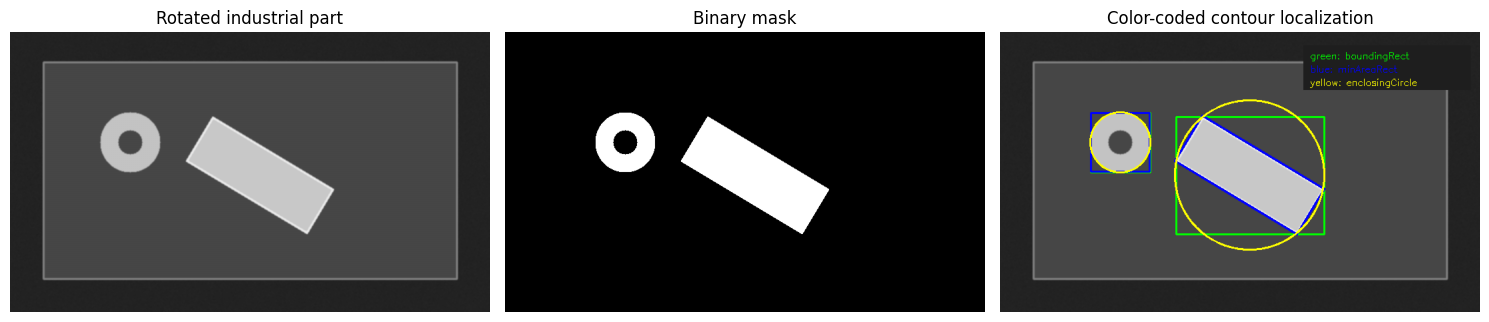

,area,green_box,yellow_radius
0,16602.0,"(264, 127, 222, 176)",113.0
1,6230.0,"(136, 121, 89, 89)",45.0


In [6]:
rot = create_rotated_part_scene()
_, rot_mask = cv2.threshold(rot, 135, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(rot_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
result = cv2.cvtColor(rot, cv2.COLOR_GRAY2BGR)
rows=[]
for c in contours:
    area=cv2.contourArea(c)
    if area<1000: continue
    x,y,w,h=cv2.boundingRect(c)
    min_rect=cv2.minAreaRect(c); min_box=cv2.boxPoints(min_rect).astype(np.int32)
    (cx,cy),rad=cv2.minEnclosingCircle(c)
    cv2.rectangle(result,(x,y),(x+w,y+h),(0,255,0),2)      # green
    cv2.drawContours(result,[min_box],0,(255,0,0),2)       # blue
    cv2.circle(result,(int(cx),int(cy)),int(rad),(0,255,255),2)  # yellow
    rows.append({'area':round(area,2),'green_box':(x,y,w,h),'yellow_radius':round(float(rad),2)})
cv2.rectangle(result,(455,20),(705,86),(30,30,30),-1)
cv2.putText(result,'green: boundingRect',(465,40),cv2.FONT_HERSHEY_SIMPLEX,0.46,(0,255,0),1)
cv2.putText(result,'blue: minAreaRect',(465,60),cv2.FONT_HERSHEY_SIMPLEX,0.46,(255,0,0),1)
cv2.putText(result,'yellow: enclosingCircle',(465,80),cv2.FONT_HERSHEY_SIMPLEX,0.46,(0,255,255),1)
df_contours = pd.DataFrame(rows)
show_images([rot, rot_mask, result], ['Rotated industrial part','Binary mask','Color-coded contour localization'], figsize=(15,5), save_path=OUTPUT_DIR/'04_contour_based_localization.png')
df_contours

### 工程觀察

結果圖中，綠色框很容易用來做普通矩形裁切，但對旋轉零件來說會比較鬆，因為它一定要保持水平/垂直方向。

藍色 rotated box 更貼合旋轉零件本身的方向，因此如果任務需要估計零件角度、姿態或緊密邊界，藍色框會比較有意義。

黃色 enclosing circle 則適合用在近似圓形物件、孔洞、墊片、圓形零件等情境。它不關心方向，而是把物件轉成「中心 + 半徑」的表示方式。

所以 contour localization 的內在邏輯是：

```text
同一個 contour
→ 可以轉成不同幾何表示
→ 根據後續任務選擇最合適的表示
```

## 5. Template Matching

**Template matching** 的本質是「外觀比對」。

它在問一個很直接的問題：

> 把這張小 template 放到大圖中的每一個可能位置，哪個位置看起來最像？

`cv2.TM_CCOEFF_NORMED` 是 normalized correlation coefficient matching。它會輸出一張 **response map**，其中每個位置的值都代表 template 放在那個位置時的相似度分數。

這個方法適合外觀穩定、方向穩定、尺寸穩定的目標，例如固定大小的 fiducial marker、固定姿態的零件標記、固定形狀的檢測區域。

但它不理解物件語意。它只是比對灰階外觀，因此遇到尺度變化、旋轉、背景中有相似圖案時，就可能不穩。

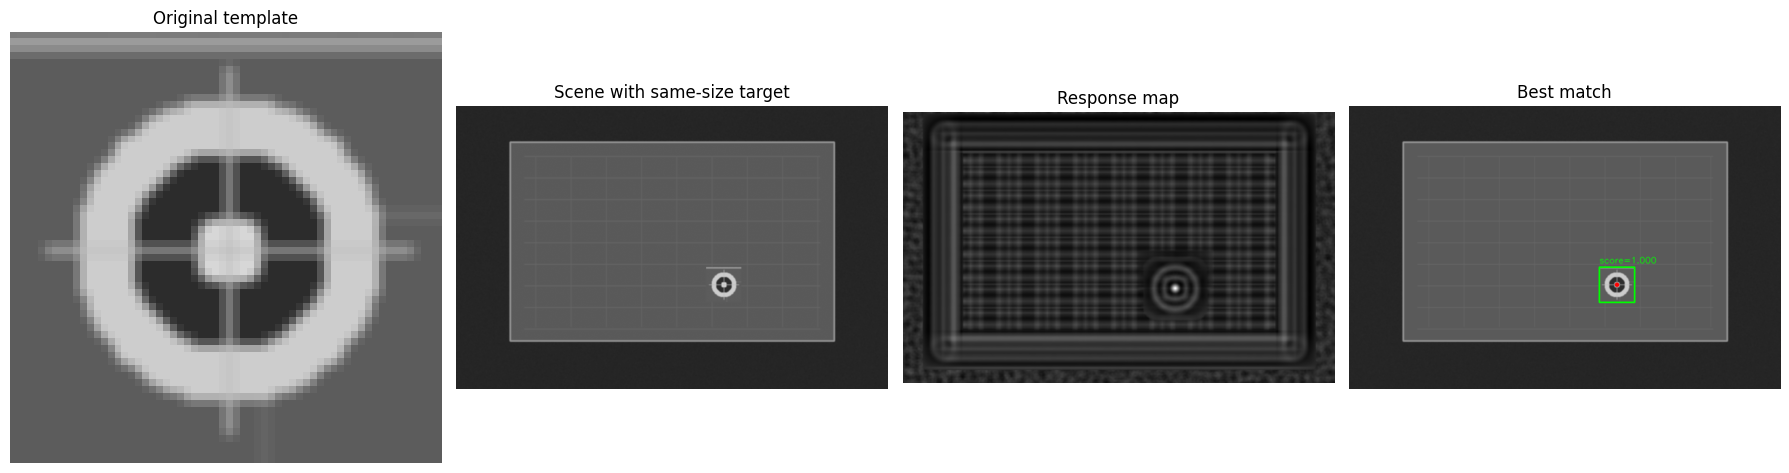

score: 1.0 location: (440, 285) true: (440, 285)


In [7]:
plain = create_plain_fixture()
template = make_fiducial_template(board, metadata['fiducials'][0], 62)
scene, _, true_box = create_template_scene(plain, template, true_pos=(440,285))
response, score, location = match_template(scene, template)

# template_match_result 會在第 10 節被重複使用。
# 避免後面其他 cell 把 result 變數覆蓋後，failure case 顯示錯誤圖片。
template_match_result = draw_box(
    scene,
    (location[0], location[1], template.shape[1], template.shape[0]),
    label=f'score={score:.3f}'
)

show_images(
    [template, scene, normalize_to_u8(response), template_match_result],
    ['Original template','Scene with same-size target','Response map','Best match'],
    figsize=(18,5),
    save_path=OUTPUT_DIR/'05_template_matching.png'
)

print('score:', round(score,4), 'location:', location, 'true:', true_box[:2])

## 6. Multi-Scale Template Matching

Single-scale template matching 有一個很強的前提：

```text
template size ≈ target size
```

如果 target 比 template 大很多，single-scale matching 就算找到相似區域，也可能只是匹配到 target 的局部，而不是完整目標。這就是為什麼這一節必須先展示 original template 與 scaled target 的真實大小關係。

**Multi-scale template matching** 的想法很簡單：

> 不要只用一個 template size，而是把 template 放大/縮小成多種尺寸，再逐一比對。

這種方法不是讓模型變聰明，而是補上「尺度搜尋」這件事。它的代價是計算量增加，因為每個 scale 都要跑一次 template matching。

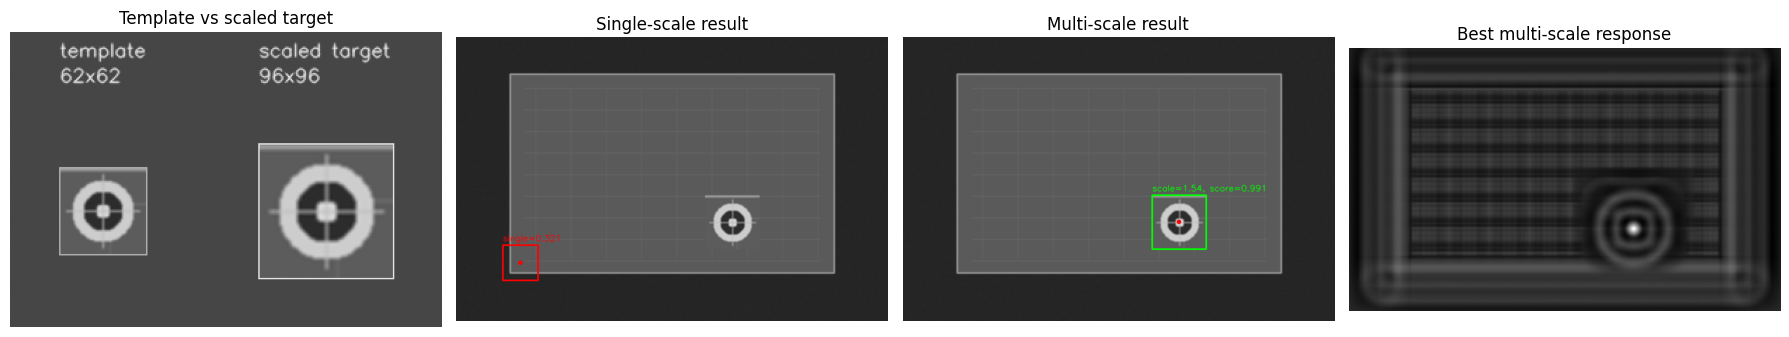

,method,score,scale
0,single_scale,0.3214,1.000
1,multi_scale,0.9913,1.538


In [8]:
scaled_scene, _, true_scaled_box = create_template_scene(plain, template, true_pos=(438,278), scale=1.55)
target_crop = crop_roi(scaled_scene, true_scaled_box)
response_single, score_single, loc_single = match_template(scaled_scene, template)
single_result = draw_box(scaled_scene, (loc_single[0], loc_single[1], template.shape[1], template.shape[0]), color=(0,0,255), label=f'single={score_single:.3f}')
best = {'score':-1}
for scale in np.linspace(0.75, 1.8, 25):
    resized = cv2.resize(template, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC if scale > 1 else cv2.INTER_AREA)
    resp, sc, loc = match_template(scaled_scene, resized)
    if sc > best['score']:
        best = {'score':float(sc), 'scale':float(scale), 'loc':loc, 'template':resized, 'response':resp}
multi_result = draw_box(scaled_scene, (best['loc'][0], best['loc'][1], best['template'].shape[1], best['template'].shape[0]), label=f"scale={best['scale']:.2f}, score={best['score']:.3f}")
df_scale = pd.DataFrame([{'method':'single_scale','score':round(score_single,4),'scale':1.0},{'method':'multi_scale','score':round(best['score'],4),'scale':round(best['scale'],3)}])

# 建立一張 comparison canvas，讓 template 和 scaled target 用相同 pixel scale 顯示
h1, w1 = template.shape[:2]
h2, w2 = target_crop.shape[:2]

gap = 80          # 拉開左右兩張圖的距離，避免文字靠太近
pad = 35
label_h = 45      # 增加上方文字空間，避免文字壓到影像

canvas_h = max(h1, h2) + label_h + pad * 2
canvas_w = w1 + gap + w2 + pad * 2

scale_comparison = np.full((canvas_h, canvas_w), 70, dtype=np.uint8)

# original template
x1 = pad
y1 = label_h + pad + (max(h1, h2) - h1) // 2
scale_comparison[y1:y1+h1, x1:x1+w1] = template

# scaled target
x2 = x1 + w1 + gap
y2 = label_h + pad + (max(h1, h2) - h2) // 2
scale_comparison[y2:y2+h2, x2:x2+w2] = target_crop

# 外框
cv2.rectangle(scale_comparison, (x1, y1), (x1+w1, y1+h1), 180, 1)
cv2.rectangle(scale_comparison, (x2, y2), (x2+w2, y2+h2), 230, 1)

# 文字標籤：放在各自圖片上方，並且不要共用同一個太靠近的位置
cv2.putText(
    scale_comparison,
    f"template",
    (x1, 18),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.45,
    230,
    1,
    cv2.LINE_AA
)

cv2.putText(
    scale_comparison,
    f"{w1}x{h1}",
    (x1, 36),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.45,
    230,
    1,
    cv2.LINE_AA
)

cv2.putText(
    scale_comparison,
    f"scaled target",
    (x2, 18),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.45,
    230,
    1,
    cv2.LINE_AA
)

cv2.putText(
    scale_comparison,
    f"{w2}x{h2}",
    (x2, 36),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.45,
    230,
    1,
    cv2.LINE_AA
)

# 用一般 subplot 顯示，避免 add_axes 造成重疊
show_images(
    [
        scale_comparison,
        single_result,
        multi_result,
        normalize_to_u8(best['response'])
    ],
    [
        'Template vs scaled target',
        'Single-scale result',
        'Multi-scale result',
        'Best multi-scale response'
    ],
    figsize=(18, 5),
    save_path=OUTPUT_DIR / '06_multiscale_template_matching.png'
)

df_scale

## 7. Feature-Based Localization

前面的 template matching 是整張 template 去滑動比對；**feature-based localization** 則換一個角度：不要要求整張 template 完全對齊，而是先找出局部穩定特徵。

`ORB` 是 **Oriented FAST and Rotated BRIEF**。

```text
FAST  = Features from Accelerated Segment Test
        用來偵測角點類型的 keypoints。

BRIEF = Binary Robust Independent Elementary Features
        用 binary descriptor 描述 keypoint 周圍的局部外觀。
```

可以把它想成：

```text
template 裡有一些局部特徵點
scene 裡也有一些局部特徵點
如果兩邊有很多點能對應
就代表 scene 中可能存在這個 template 所代表的物件
```

但這一節要特別注意：matched points 只是中間證據，不是最終定位結果。它們告訴我們「哪些點可能對應」，但還沒有告訴我們完整物件邊界在哪裡。下一節的 homography 才會把這些點轉成物件級定位。

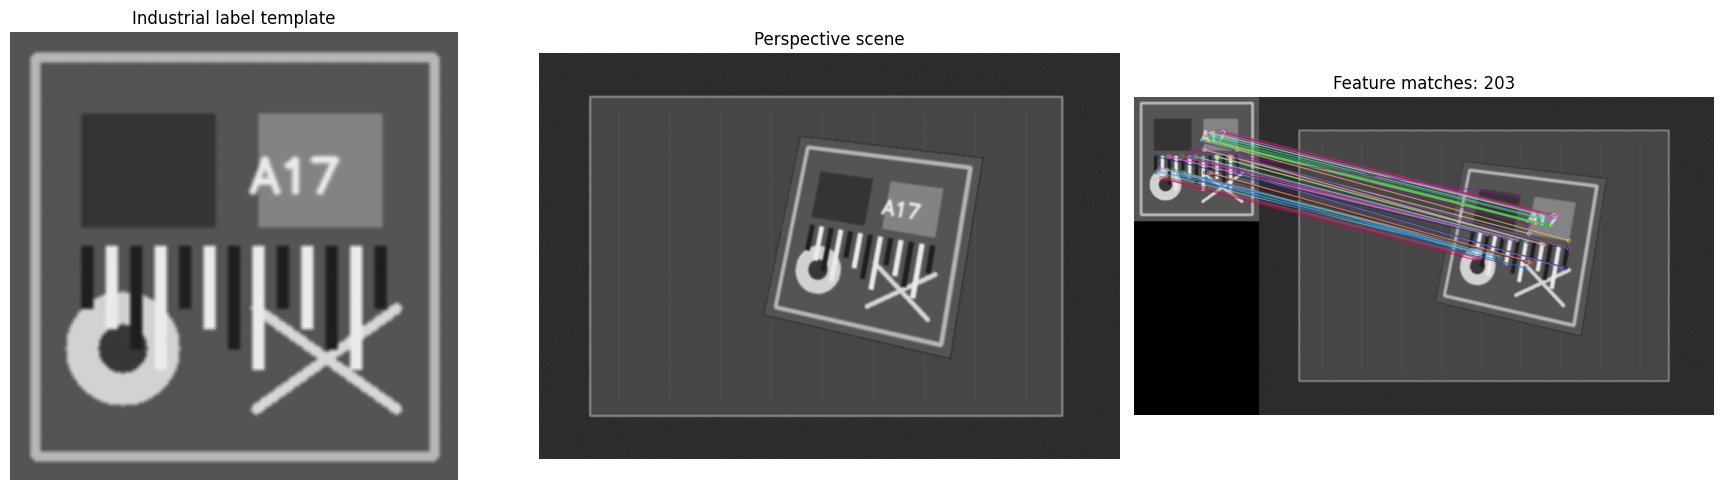

good matches: 203


In [9]:
feature_template = create_feature_panel()
feature_scene, src_corners, dst_corners = create_homography_scene(feature_template)
orb = cv2.ORB_create(nfeatures=1500)
kp_template, des_template = orb.detectAndCompute(feature_template, None)
kp_scene, des_scene = orb.detectAndCompute(feature_scene, None)
matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
knn = matcher.knnMatch(des_template, des_scene, k=2)
good = []
for pair in knn:
    if len(pair) < 2: continue
    m, n = pair
    if m.distance < 0.78 * n.distance: good.append(m)
match_view = cv2.drawMatches(feature_template, kp_template, feature_scene, kp_scene, good[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
show_images([feature_template, feature_scene, match_view], ['Industrial label template','Perspective scene',f'Feature matches: {len(good)}'], figsize=(18,5), save_path=OUTPUT_DIR/'07_feature_based_matching.png')
print('good matches:', len(good))

## 8. Homography-Based Object Localization

Feature matching 找到的是點對點對應，但工程上通常需要的是物件位置。

**Homography** 可以把多個 matched points 轉成一個平面物件的幾何轉換。它是一個 3×3 matrix，用來描述同一個平面在兩個視角之間如何映射。

`RANSAC` 是 **Random Sample Consensus**。它的作用是從一堆 matches 中找出幾何上合理的一群點：

```text
inlier  = 符合同一個 homography 的 match
outlier = 不符合這個幾何關係的 match
```

用人話說，feature matching 是「找線索」，homography 是「把線索拼成物件位置」。最後的綠色四邊形就是 template 被投影到 scene 中的位置。

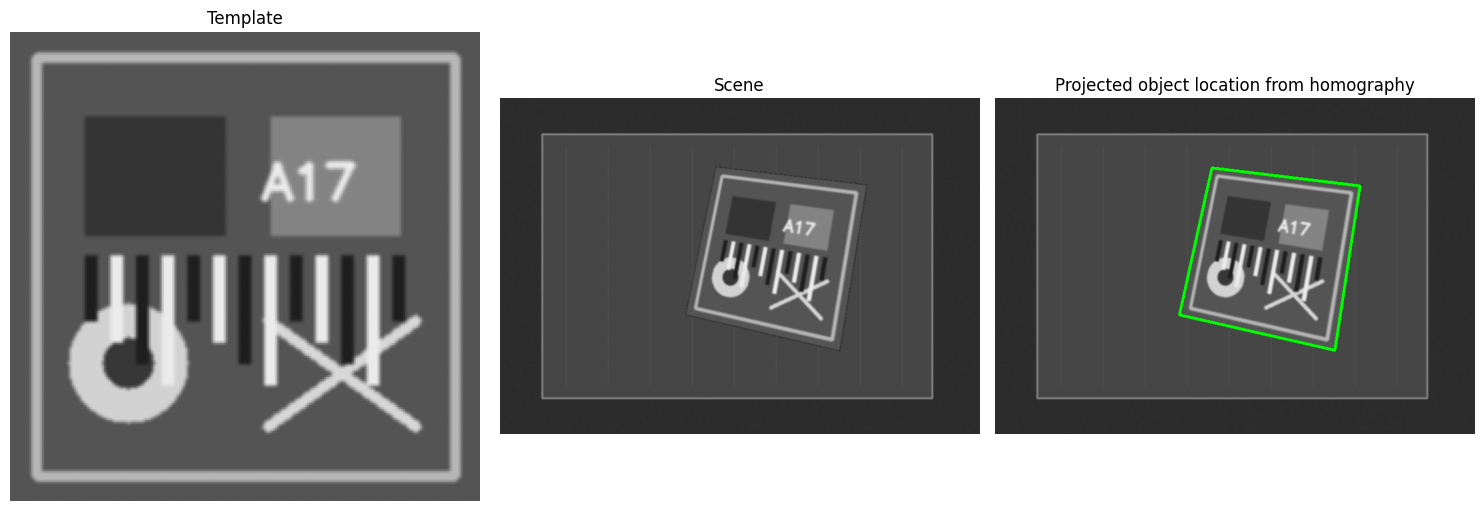

inliers: 195 / 203 ratio: 0.961


In [10]:
src_pts = np.float32([kp_template[m.queryIdx].pt for m in good]).reshape(-1,1,2)
dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1,1,2)
H, inlier_mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
homography_result = cv2.cvtColor(feature_scene, cv2.COLOR_GRAY2BGR)
projected = cv2.perspectiveTransform(src_corners.reshape(-1,1,2), H)
cv2.polylines(homography_result, [np.int32(projected)], True, (0,255,0), 3)
inlier_count = int(inlier_mask.sum())
inlier_ratio = inlier_count / len(good)
show_images([feature_template, feature_scene, homography_result], ['Template','Scene','Projected object location from homography'], figsize=(15,5), save_path=OUTPUT_DIR/'08_homography_based_localization.png')
print('inliers:', inlier_count, '/', len(good), 'ratio:', round(inlier_ratio,3))

## 9. Reliability Analysis

定位結果不能因為畫出框就直接接受。可靠性分析要回答的是：

> 這個位置有沒有足夠證據支持？

不同方法的可靠性證據不同：

```text
Template matching:
    看 best score、second-best score、score gap、response map。

Feature matching:
    看 good matches、RANSAC inliers、inlier ratio。

Mask localization:
    看 area、aspect ratio、component count、boundary 是否合理。
```

這一節的目標不是增加新的定位方法，而是建立「不要只看圖上有沒有框」的工程習慣。

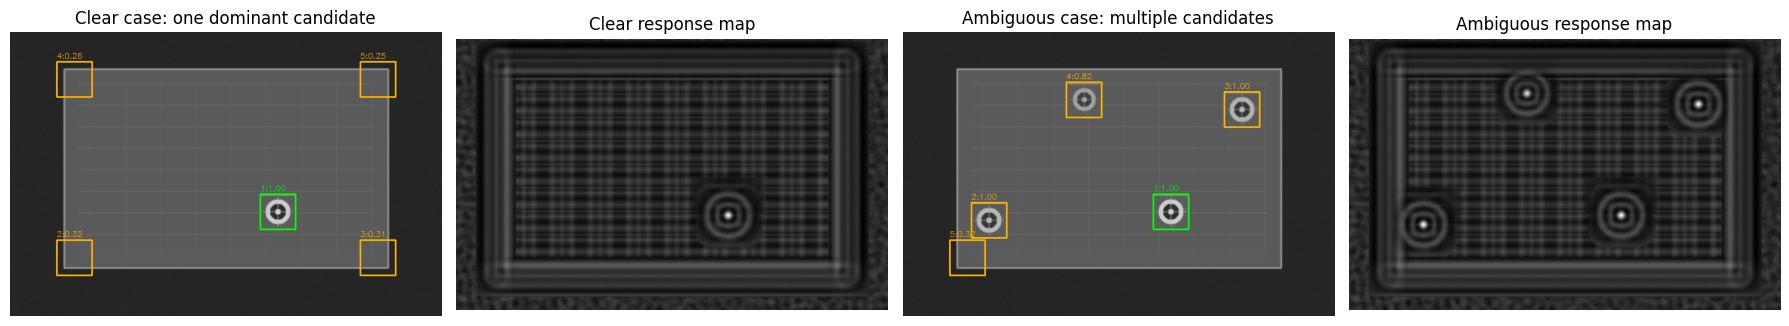

,case,best,second,gap
0,clear,1.0,0.321439,0.678561
1,ambiguous,1.0,0.999938,0.000062


In [11]:
top_clear = top_k_locations(response, 5, 45)
clear_view = draw_topk(scene, top_clear, template.shape)
amb_scene, _, _ = create_template_scene(plain, template, true_pos=(440,285), clutter=True)
amb_response, _, _ = match_template(amb_scene, template)
top_amb = top_k_locations(amb_response, 5, 45)
amb_view = draw_topk(amb_scene, top_amb, template.shape)
gap_clear = top_clear[0][2] - top_clear[1][2]
gap_amb = top_amb[0][2] - top_amb[1][2]
df_reliability = pd.DataFrame([{'case':'clear','best':top_clear[0][2],'second':top_clear[1][2],'gap':gap_clear},{'case':'ambiguous','best':top_amb[0][2],'second':top_amb[1][2],'gap':gap_amb}])
show_images([clear_view, normalize_to_u8(response), amb_view, normalize_to_u8(amb_response)], ['Clear case: one dominant candidate','Clear response map','Ambiguous case: multiple candidates','Ambiguous response map'], figsize=(18,5), save_path=OUTPUT_DIR/'10_template_matching_reliability.png')
df_reliability

### 9.2 Feature Matching Reliability

Feature matching 不能只看 good matches 數量。

很多 matches 可能只是局部外觀相似，但不一定能組成一致的物件幾何。RANSAC inliers 的重要性就在這裡：它會檢查這些 matches 是否能支持同一個 homography。

可以這樣理解：

```text
good matches = 可能對得上
inliers      = 在幾何上真的站得住腳
```

如果 good matches 很多，但 inlier ratio 很低，代表很多匹配其實不一致，定位結果就不應該被直接相信。

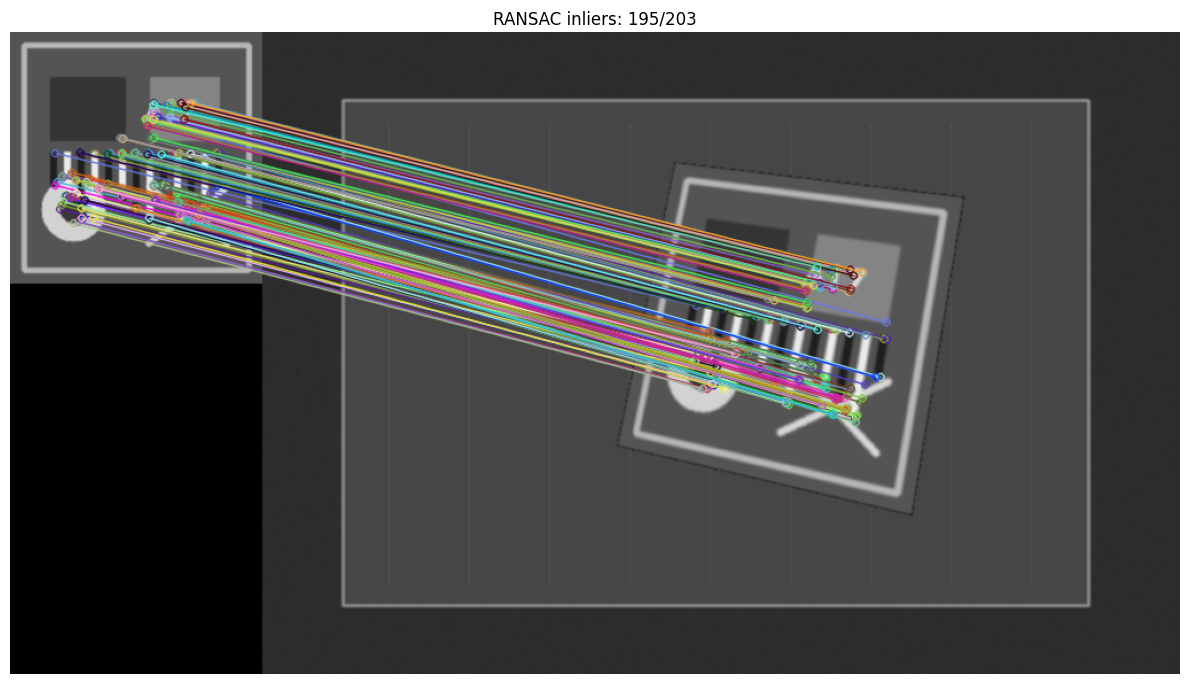

In [12]:
inlier_view = cv2.drawMatches(feature_template, kp_template, feature_scene, kp_scene, good, None, matchesMask=inlier_mask.ravel().tolist(), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
show_images([inlier_view], [f'RANSAC inliers: {inlier_count}/{len(good)}'], figsize=(12,7), save_path=OUTPUT_DIR/'09_feature_reliability_inliers.png')

### 9.3 Mask-Based Reliability

Mask-based localization 的可靠性通常可以用簡單幾何條件先過濾。

例如在一個零件檢測任務中，正常零件不應該太小，也不應該是過度細長的形狀。因此可以檢查：

```text
area 是否在合理範圍
aspect ratio 是否合理
component count 是否符合預期
centroid 是否落在合理區域
```

這些檢查看起來很基礎，但在實務 inspection pipeline 中非常有用，因為它們能快速排除明顯不合理的候選物件。

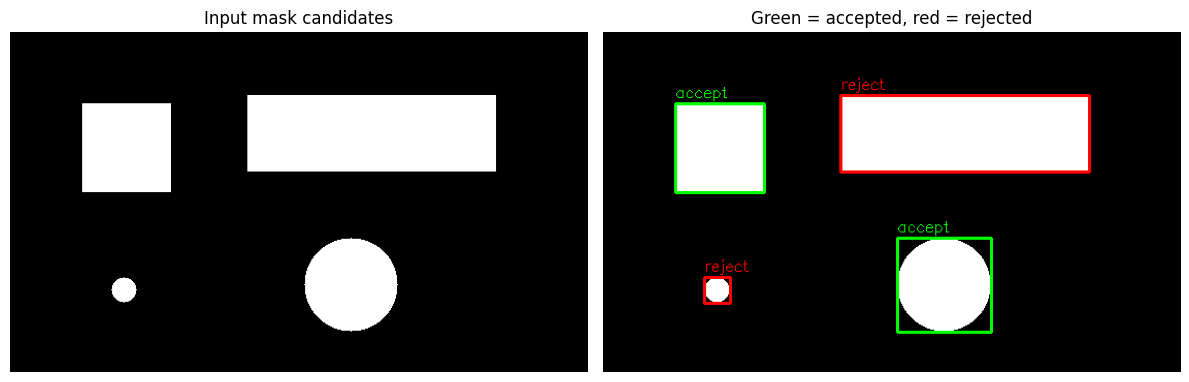

,area,aspect_ratio,accepted
0,17834,3.257,False
1,7396,1.000,True
2,6361,1.000,True
3,441,1.000,False


In [13]:
reliability_mask = np.zeros((330,560), dtype=np.uint8)
cv2.rectangle(reliability_mask,(70,70),(155,155),255,-1)
cv2.rectangle(reliability_mask,(230,62),(470,135),255,-1)
cv2.circle(reliability_mask,(110,250),12,255,-1)
cv2.circle(reliability_mask,(330,245),45,255,-1)
num, labels, stats, centroids = cv2.connectedComponentsWithStats(reliability_mask, 8)
result = cv2.cvtColor(reliability_mask, cv2.COLOR_GRAY2BGR)
rows=[]
for i in range(1,num):
    x,y,w,h,area = stats[i]; aspect = w/h
    accepted = (1000 <= area <= 12000) and (0.6 <= aspect <= 1.6)
    color = (0,255,0) if accepted else (0,0,255)
    cv2.rectangle(result,(x,y),(x+w,y+h),color,2)
    cv2.putText(result,'accept' if accepted else 'reject',(x,max(15,y-6)),cv2.FONT_HERSHEY_SIMPLEX,0.48,color,1)
    rows.append({'area':int(area),'aspect_ratio':round(aspect,3),'accepted':accepted})
df_mask_reliability = pd.DataFrame(rows)
show_images([reliability_mask, result], ['Input mask candidates','Green = accepted, red = rejected'], figsize=(12,5), save_path=OUTPUT_DIR/'11_mask_localization_reliability.png')
df_mask_reliability

## 10. Failure Case Analysis

Failure cases 的目的不是單純展示「方法會失敗」，而是要看出方法的假設在哪裡被破壞。

本章前面其實已經隱含了各方法的假設：

```text
template matching 假設外觀、尺度、旋轉穩定
multi-scale matching 放寬尺度穩定的假設
feature matching 需要足夠且有辨識性的局部特徵
homography 假設目標大致是平面，且 matches 幾何一致
mask localization 假設 foreground/background 可分離
```

這一節用幾個對比案例整理這些限制。重點不是把所有失敗情境都窮舉完，而是理解「為什麼這種條件會讓方法變差」。

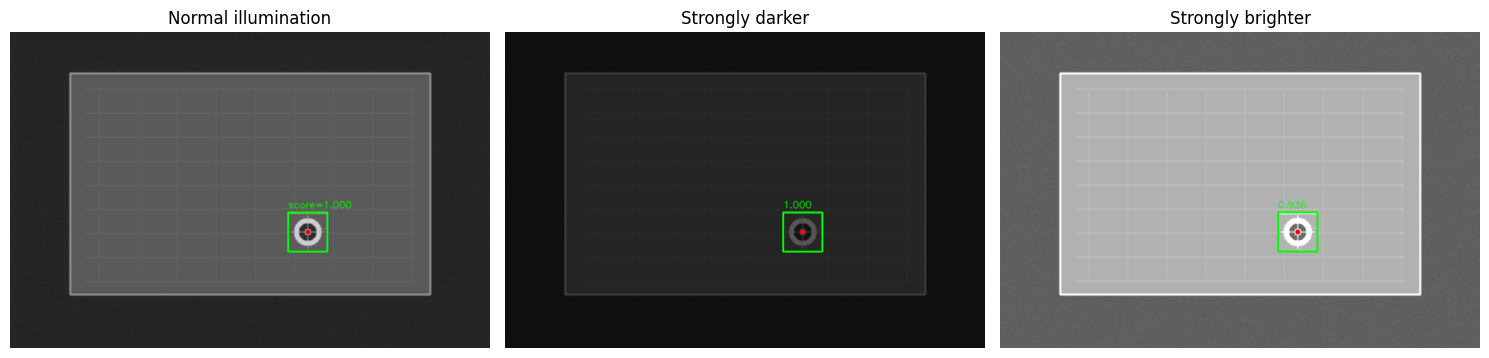

,case,score,x,y
0,normal,1.0000,440,285
1,dark,1.0000,440,285
2,bright,0.9364,440,285


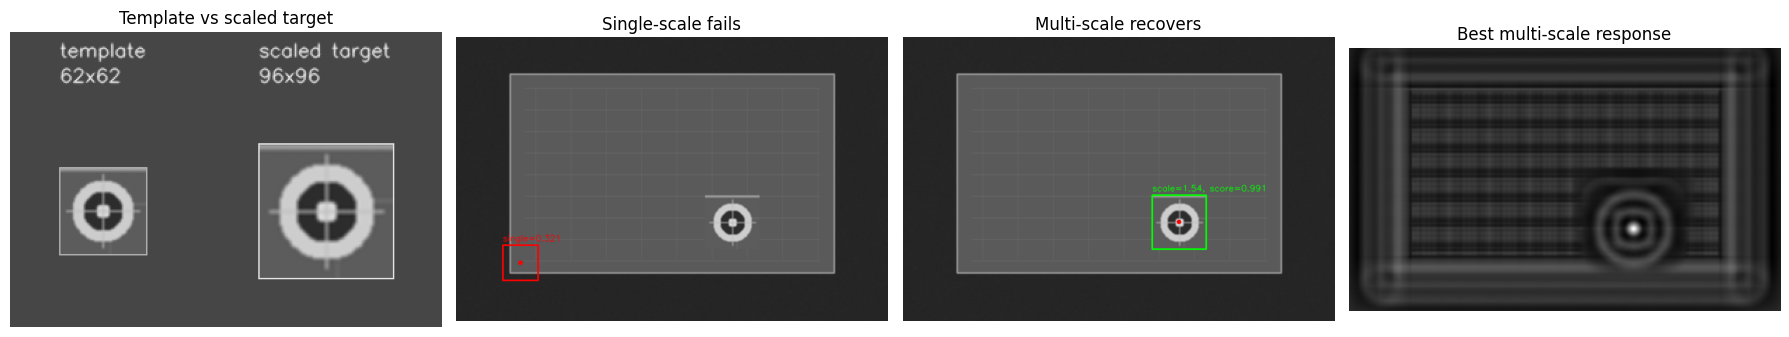

,method,score,scale
0,single_scale,0.3214,1.000
1,multi_scale,0.9913,1.538


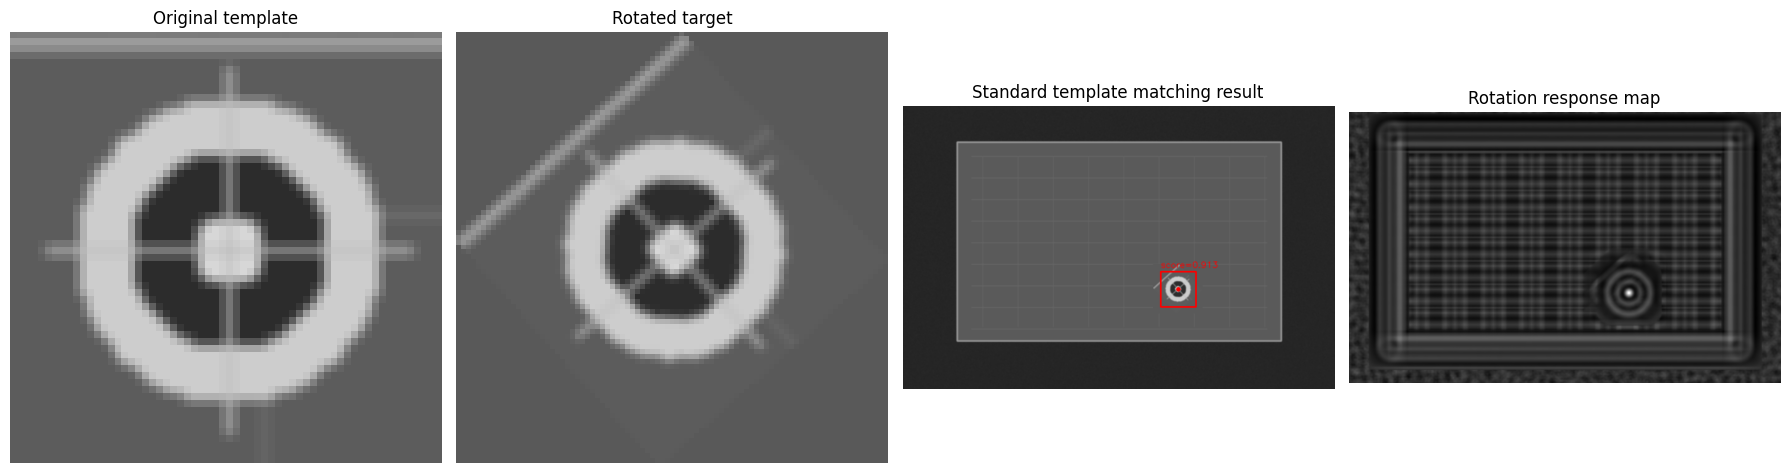

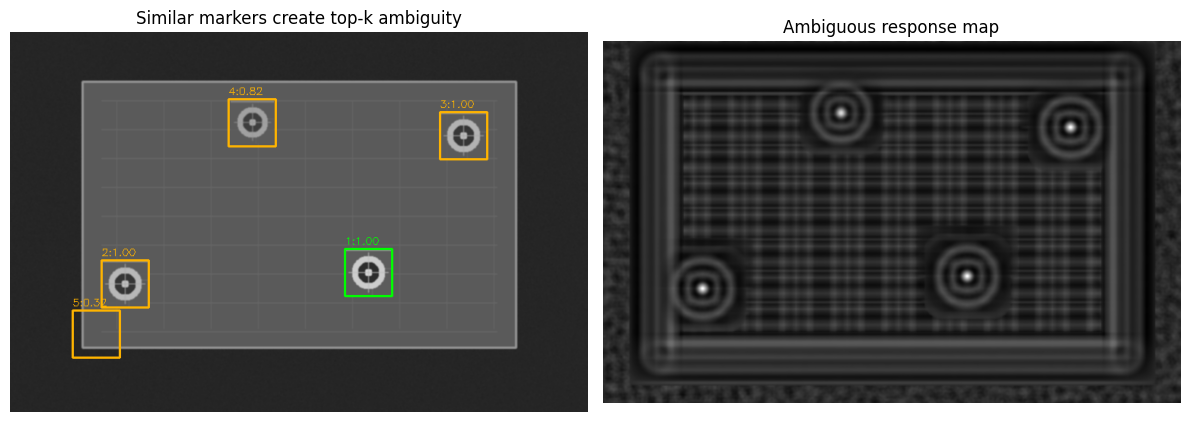

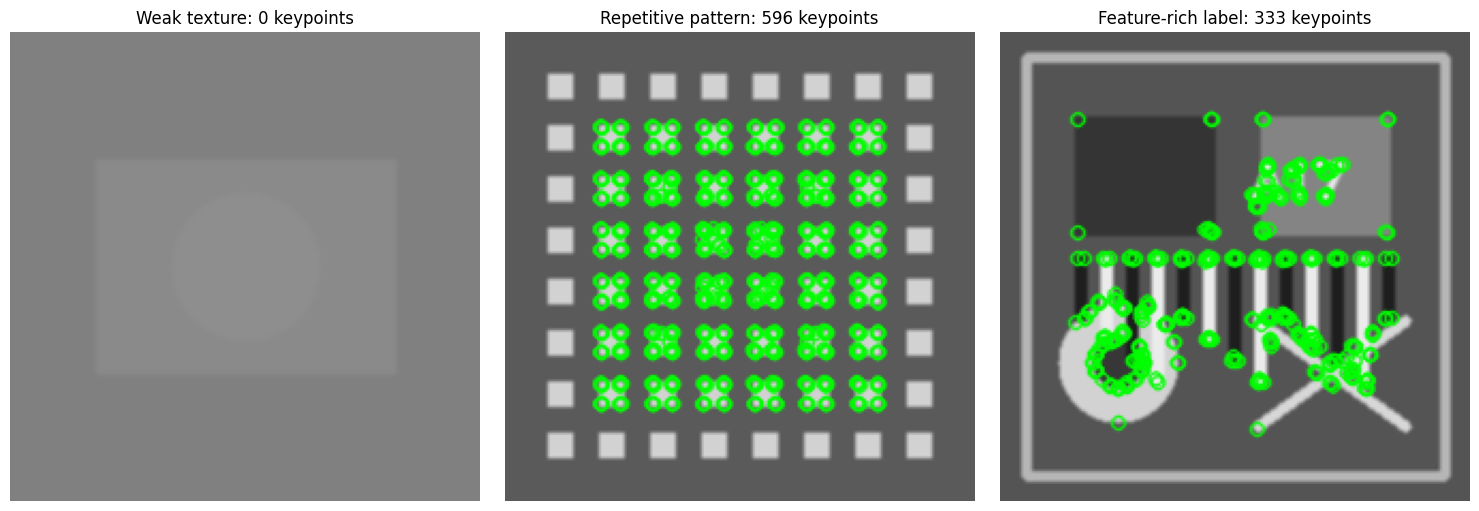

,case,keypoints
0,weak_low_texture_part,0
1,repetitive_grid_pattern,596
2,feature_rich_label,333


In [14]:
# ------------------------------------------------------------
# 10.1 Illumination change
# ------------------------------------------------------------
# 強烈光照改變會讓灰階外觀分布變化。
# Normalized template matching 能降低部分影響，但不是完全免疫。
dark = np.clip(scene.astype(np.float32) * 0.42, 0, 255).astype(np.uint8)
bright = np.clip(scene.astype(np.float32) * 1.55 + 38, 0, 255).astype(np.uint8)

_, sd, ld = match_template(dark, template)
_, sb, lb = match_template(bright, template)

dark_result = draw_box(
    dark,
    (ld[0], ld[1], template.shape[1], template.shape[0]),
    label=f'{sd:.3f}'
)

bright_result = draw_box(
    bright,
    (lb[0], lb[1], template.shape[1], template.shape[0]),
    label=f'{sb:.3f}'
)

df_light = pd.DataFrame([
    {'case':'normal', 'score':round(float(score),4), 'x':int(location[0]), 'y':int(location[1])},
    {'case':'dark', 'score':round(float(sd),4), 'x':int(ld[0]), 'y':int(ld[1])},
    {'case':'bright', 'score':round(float(sb),4), 'x':int(lb[0]), 'y':int(lb[1])},
])

show_images(
    [template_match_result, dark_result, bright_result],
    ['Normal illumination','Strongly darker','Strongly brighter'],
    figsize=(15,5),
    save_path=OUTPUT_DIR/'12_failure_illumination_change.png'
)

display(df_light)


# ------------------------------------------------------------
# 10.2 Scale change
# ------------------------------------------------------------
# 這裡沿用第 6 節已確認滿意的 scale_comparison。
# 讓 original template 和 scaled target 使用同一個 pixel scale 顯示，
# 才能清楚說明 single-scale 為什麼不適合。
show_images(
    [scale_comparison, single_result, multi_result, normalize_to_u8(best['response'])],
    ['Template vs scaled target', 'Single-scale fails', 'Multi-scale recovers', 'Best multi-scale response'],
    figsize=(18,5),
    save_path=OUTPUT_DIR/'13_failure_scale_change.png'
)

display(df_scale)


# ------------------------------------------------------------
# 10.3 Rotation change
# ------------------------------------------------------------
# Standard template matching 不會自動旋轉 template。
# 當 target 旋轉後，原本 template 的像素排列就不再對齊。
rotated_scene, rotated_target, _ = create_template_scene(
    plain,
    template,
    true_pos=(440, 280),
    rotate_angle=42
)

rotation_response, rotation_score, rotation_loc = match_template(rotated_scene, template)

rotation_result = draw_box(
    rotated_scene,
    (rotation_loc[0], rotation_loc[1], template.shape[1], template.shape[0]),
    color=(0,0,255),
    label=f'score={rotation_score:.3f}'
)

show_images(
    [template, rotated_target, rotation_result, normalize_to_u8(rotation_response)],
    ['Original template', 'Rotated target', 'Standard template matching result', 'Rotation response map'],
    figsize=(18,5),
    save_path=OUTPUT_DIR/'14_failure_rotation_change.png'
)


# ------------------------------------------------------------
# 10.4 Background clutter
# ------------------------------------------------------------
# 背景中如果出現多個相似 marker，template matching 會產生多個高分候選。
# 這不是 bug，而是 template matching 只看外觀相似度造成的自然結果。
show_images(
    [amb_view, normalize_to_u8(amb_response)],
    ['Similar markers create top-k ambiguity', 'Ambiguous response map'],
    figsize=(12,5),
    save_path=OUTPUT_DIR/'15_failure_background_clutter.png'
)


# ------------------------------------------------------------
# 10.5 Weak or repetitive features
# ------------------------------------------------------------
# Feature matching 需要有辨識性的局部特徵。
# 低紋理可能 keypoints 太少；重複紋理可能 keypoints 很多但不夠獨特。
weak_texture, repetitive_pattern = create_low_texture_and_repetitive()

kp_weak, _ = orb.detectAndCompute(weak_texture, None)
kp_repetitive, _ = orb.detectAndCompute(repetitive_pattern, None)

weak_view = cv2.drawKeypoints(weak_texture, kp_weak, None, color=(0,255,0))
repetitive_view = cv2.drawKeypoints(repetitive_pattern, kp_repetitive, None, color=(0,255,0))
feature_rich_view = cv2.drawKeypoints(feature_template, kp_template, None, color=(0,255,0))

df_feature_failure = pd.DataFrame([
    {'case':'weak_low_texture_part', 'keypoints':len(kp_weak)},
    {'case':'repetitive_grid_pattern', 'keypoints':len(kp_repetitive)},
    {'case':'feature_rich_label', 'keypoints':len(kp_template)},
])

show_images(
    [weak_view, repetitive_view, feature_rich_view],
    [f'Weak texture: {len(kp_weak)} keypoints',
     f'Repetitive pattern: {len(kp_repetitive)} keypoints',
     f'Feature-rich label: {len(kp_template)} keypoints'],
    figsize=(15,5),
    save_path=OUTPUT_DIR/'16_failure_weak_repetitive_features.png'
)

display(df_feature_failure)

## 11. Method Selection Guide

方法選擇取決於影像能提供什麼證據。

如果 foreground 和 background 很容易分開，mask-based localization 通常最直接。  
如果邊界形狀和方向很重要，contours 比單純 components 更有用。  
如果目標外觀和尺度固定，template matching 很簡潔。  
如果目標尺度會變，multi-scale template matching 更合理。  
如果目標有豐富紋理且可能有視角變化，feature matching 和 homography 才有發揮空間。

所以選方法時不應該問「哪個演算法最好」，而是問：

> 這張影像中最穩定、最可靠的證據是什麼？

In [15]:
pd.DataFrame([
{'method':'mask_components','best_for':'separable bright/dark parts'},
{'method':'contours','best_for':'shape and orientation inspection'},
{'method':'template_matching','best_for':'fixed appearance and scale'},
{'method':'multi_scale_template_matching','best_for':'moderate scale changes'},
{'method':'ORB_feature_matching','best_for':'textured industrial marks'},
{'method':'homography','best_for':'planar object under perspective change'}])

,method,best_for
0,mask_components,separable bright/dark parts
1,contours,shape and orientation inspection
2,template_matching,fixed appearance and scale
3,multi_scale_template_matching,moderate scale changes
4,ORB_feature_matching,textured industrial marks
5,homography,planar object under perspective change


## 12. Final Engineering Pipeline

可用的 localization pipeline 不應該只輸出一張 annotated image，而應該同時輸出位置與可靠性證據。

比較完整的輸出包含：

```text
annotated image
bounding box
ROI crop
matching score
score gap
pass/fail decision
response map
```

這樣做的原因是：工程流程不能只靠肉眼看圖。當結果要被後續模型、量測系統或自動化流程使用時，必須有數值證據可以判斷它是否可靠。

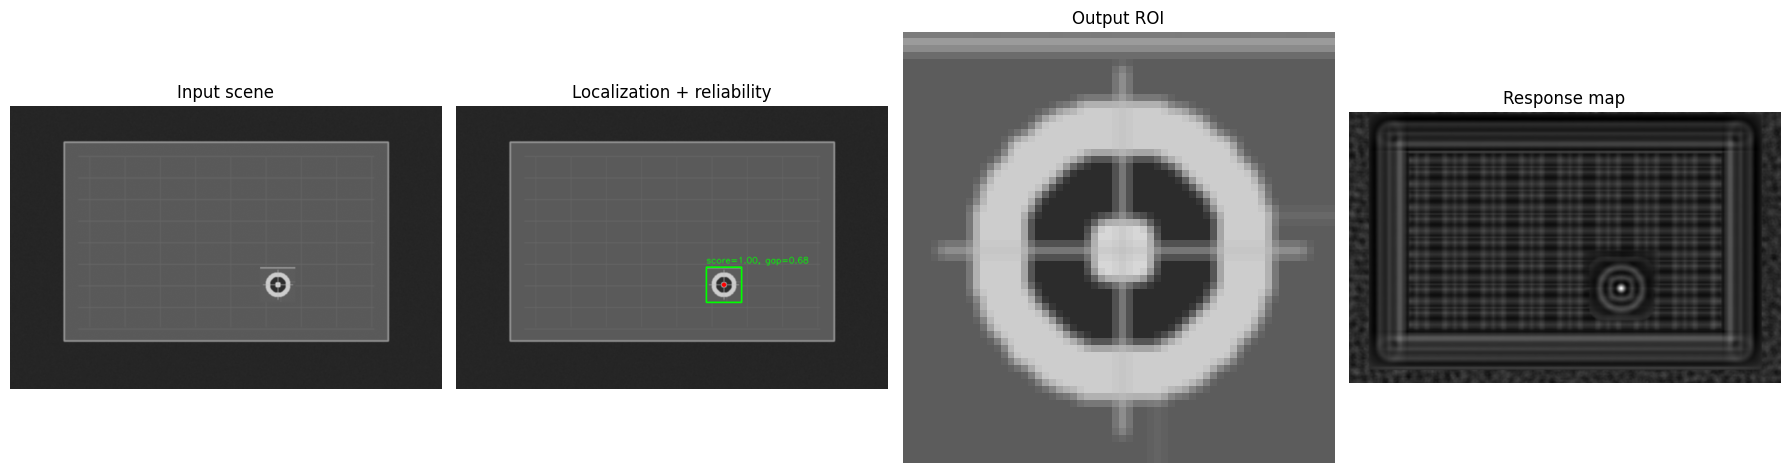

{'box': (440, 285, 62, 62),
 'score': 0.9999998807907104,
 'gap': 0.6785609126091003,
 'passed': True}

In [16]:
def localize_with_template_and_check(scene, template, score_threshold=0.72, gap_threshold=0.02):
    response, best_score, best_loc = match_template(scene, template)
    top2 = top_k_locations(response, 2, 45)
    gap = top2[0][2] - top2[1][2]
    box = (best_loc[0], best_loc[1], template.shape[1], template.shape[0])
    passed = (best_score >= score_threshold) and (gap >= gap_threshold)
    annotated = draw_box(scene, box, color=(0,255,0) if passed else (0,0,255), label=f'score={best_score:.2f}, gap={gap:.2f}')
    roi = crop_roi(scene, box)
    return {'box':box, 'score':best_score, 'gap':gap, 'passed':passed, 'annotated':annotated, 'roi':roi, 'response':response}
pipe = localize_with_template_and_check(scene, template)
show_images([scene, pipe['annotated'], pipe['roi'], normalize_to_u8(pipe['response'])], ['Input scene','Localization + reliability','Output ROI','Response map'], figsize=(18,5), save_path=OUTPUT_DIR/'17_final_engineering_pipeline.png')
{k:v for k,v in pipe.items() if k not in ['annotated','roi','response']}

## 全章工程筆記補充

這一章的主線不是把多個 OpenCV 函式各自示範一次，而是建立一條完整的定位思路。

第一步先確認 localization 的本質：它不是圖上的框，而是一組可以被後續程式使用的座標資料。只要這組座標錯了，後面所有 ROI 裁切、量測、分類或檢測都會錯。

第二步是確認座標系統。OpenCV 的 x/y 方向、NumPy 的 slicing 順序，都是很容易讓 pipeline 出錯的地方。這些細節看起來基礎，但它們決定結果能不能真的被工程流程使用。

Mask-based localization 的核心是「先得到可信的前景區域，再把區域轉成物件」。所以 clean mask 是否真的比 initial mask 好，是這個方法能不能被信任的關鍵。這裡透過 small regions 數量與視覺結果一起檢查 cleanup 是否有效。

Contour-based localization 的重點是邊界幾何。綠色 axis-aligned bounding box 適合普通裁切，但不理解物件方向；藍色 rotated box 能跟著零件旋轉，因此更適合方向量測；黃色 enclosing circle 則適合圓形近似或半徑量測。這些表示方式不是互相取代，而是對應不同需求。

Template matching 的重點是 response map。它不是模型理解物件，而是把 template 放到每個位置比較外觀相似度。Multi-scale template matching 則是在補足 template size 和 target size 不一致的問題，因此結果圖必須先讓讀者看到原始 template 和放大後 target 的實際大小差異。

Feature-based localization 只做到 matched points 還不算完整定位。Matched points 只是局部對應證據；真正把這些點轉成物件位置的是 homography。Homography 會把 template 的四個角投影到 scene 中，這樣才會得到物件級別的位置。

Reliability analysis 是整章最重要的工程補強。Template matching 要看 score gap，因為最高分如果沒有明顯高於第二名，就代表候選位置很多、結果不穩。Feature matching 要看 inliers，因為 matches 多不代表幾何一致。Mask localization 要看 area 與 aspect ratio，因為太小或形狀異常的 component 很可能不是正常零件。

Failure cases 的目的不是展示失敗而已，而是讓人知道方法的假設在哪裡被破壞。尺度變化破壞固定 template size；旋轉破壞 template 和 target 的像素對齊；背景干擾製造多個相似候選點；低紋理讓 feature points 不足；重複紋理則讓 feature matches 變得模糊。

最後，這一章的核心結論是：

```text
定位不是只有找位置，
而是找出一個可以被後續流程使用，
並且有足夠證據支持的位置。
```